<a href="https://colab.research.google.com/github/mchlgho22/Project2_Object_Detection_Person_Yolov8/blob/main/ObjectDetection_Yolo8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# 1. MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ================================
# 2. INSTALL DEPENDENCIES
# ================================
!pip install ultralytics pycocotools tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.4 MB/s eta 0:00:00


In [ ]:
# ================================
# 3. DOWNLOAD DATASET COCO
# ================================
%cd /content
!mkdir -p coco_temp
%cd coco_temp

!wget -q http://images.cocodataset.org/zips/train2017.zip
!wget -q http://images.cocodataset.org/zips/val2017.zip
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip

# ================================
# EXTRACT DATASET
# ================================
!unzip -q train2017.zip
!unzip -q val2017.zip
!unzip -q annotations_trainval2017.zip

# ================================
# PINDAH KE GOOGLE DRIVE
# ================================
# BASE_DIR_COCO = "/content/drive/MyDrive/coco"
# !mkdir -p $BASE_DIR_COCO

# !mv train2017 $BASE_DIR_COCO/
# !mv val2017 $BASE_DIR_COCO/
# !mv annotations $BASE_DIR_COCO/

# ================================
# (OPSIONAL) BERSIHKAN
# ================================
# %cd /content
# !rm -rf coco_temp

/content
/content/coco_temp


In [ ]:
# ================================
# 4. SETUP FOLDER
# ================================
import os, shutil

BASE_DIR = "/content/drive/MyDrive/yolo_person"
DATASET_DIR = f"{BASE_DIR}/datasets/person"

COCO_IMG_TRAIN = "/content/coco_temp/train2017"
COCO_IMG_VAL = "/content/coco_temp/val2017"
ANN_FILE = "/content/coco_temp/annotations/instances_train2017.json"

# Hapus folder lama jika ada
shutil.rmtree(BASE_DIR, ignore_errors=True)

os.makedirs(f"{DATASET_DIR}/images/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/images/val", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/labels/val", exist_ok=True)

In [ ]:
import os

# print("Cek isi folder train2017:")
# print(len(os.listdir("/content/drive/MyDrive/coco/train2017")))

print("Cek contoh file:")
print(os.path.exists("/content/coco_temp/train2017/000000521106.jpg"))

In [ ]:
# ================================
# 5. FILTER 5000 GAMBAR PERSON
# ================================
from pycocotools.coco import COCO
import random
from tqdm import tqdm
import shutil

random.seed(42)

coco = COCO(ANN_FILE)

cat_ids = coco.getCatIds(catNms=['person'])
img_ids = coco.getImgIds(catIds=cat_ids)

# ambil 5000 atau kurang jika dataset tidak cukup
img_ids = random.sample(img_ids, min(5000, len(img_ids)))

# split train 80%, val 20%
split = int(0.8 * len(img_ids))
train_ids = img_ids[:split]
val_ids = img_ids[split:]

loading annotations into memory...
Done (t=21.23s)
creating index...
index created!


In [ ]:
# ================================
# 6. CONVERT COCO → YOLO
# ================================
def convert_bbox(size, box):
    dw = 1./size[0]
    dh = 1./size[1]
    x = (box[0] + box[2]/2.0) * dw
    y = (box[1] + box[3]/2.0) * dh
    w = box[2] * dw
    h = box[3] * dh
    return (x, y, w, h)

def process(ids, split_name):
    for img_id in tqdm(ids):
        img = coco.loadImgs(img_id)[0]
        file_name = img['file_name']

        src_path = f"{COCO_IMG_TRAIN}/{file_name}"
        if not os.path.exists(src_path):
            src_path = f"{COCO_IMG_VAL}/{file_name}"
            if not os.path.exists(src_path):
                print(f"Missing image: {file_name}")
                continue

        dst_img = f"{DATASET_DIR}/images/{split_name}/{file_name}"
        shutil.copy(src_path, dst_img)

        ann_ids = coco.getAnnIds(imgIds=img_id, catIds=cat_ids)
        anns = coco.loadAnns(ann_ids)

        label_path = f"{DATASET_DIR}/labels/{split_name}/{file_name.replace('.jpg','.txt')}"
        with open(label_path, "w") as f:
            if len(anns) == 0:
                f.write("")  # safety: kosong
            for ann in anns:
                bbox = convert_bbox((img['width'], img['height']), ann['bbox'])
                f.write(f"0 {' '.join(map(str,bbox))}\n")

process(train_ids, "train")
process(val_ids, "val")

100%|██████████| 1000/1000 [00:23<00:00, 42.31it/s]


In [ ]:
# ================================
# 7. BUAT YAML
# ================================
yaml_content = f"""
path: {DATASET_DIR}
train: images/train
val: images/val

names:
  0: person
"""

with open(f"{DATASET_DIR}/data.yaml", "w") as f:
    f.write(yaml_content)


In [ ]:
# ================================
# 8. TRAIN YOLOv8
# ================================
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{DATASET_DIR}/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    name="person_model"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolo_person/datasets/person/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_

In [ ]:
# ================================
# 9. Save Model (AUTO GLOB VERSION)
# ================================
import os
import shutil
import glob

BASE_DIR = "/content/drive/MyDrive/yolo_person"
SAVE_DIR = f"{BASE_DIR}/model"

os.makedirs(SAVE_DIR, exist_ok=True)

# ================================
# DETEKSI RUN TERBARU
# ================================
runs = glob.glob("/content/coco_temp/runs/detect/person_model*")

if len(runs) == 0:
    raise Exception("Folder training tidak ditemukan!")

# sort berdasarkan waktu (terbaru terakhir)
latest_run = max(runs, key=os.path.getmtime)

print("📂 Latest run detected:", latest_run)

# ================================
# LIST FILE YANG MAU DISIMPAN
# ================================
files_to_copy = [
    "weights/best.pt",
    "weights/last.pt",
    "results.csv",
    "results.png",
    "confusion_matrix.png"
]

# ================================
# COPY FILE
# ================================
for file in files_to_copy:
    src = os.path.join(latest_run, file)
    dst = os.path.join(SAVE_DIR, os.path.basename(file))

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ Copied: {file}")
    else:
        print(f"⚠️ Not found: {file}")

print("\n🎉 Semua file penting sudah disimpan ke Google Drive!")

📂 Latest run detected: /content/coco_temp/runs/detect/person_model
✅ Copied: weights/best.pt
✅ Copied: weights/last.pt
✅ Copied: results.csv
✅ Copied: results.png
✅ Copied: confusion_matrix.png

🎉 Semua file penting sudah disimpan ke Google Drive!


In [ ]:
# ================================
# 10. Load Model
# ================================
from ultralytics import YOLO

LOAD_DIR = "/content/drive/MyDrive/yolo_person/model"
model = YOLO(f"{LOAD_DIR}/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ================================
# 11. EVALUATE MODEL
# ================================
metrics = model.val(
    data=f"{DATASET_DIR}/data.yaml",
    split="val",
    imgsz=640,
    batch=16,
    conf=0.001,   # threshold rendah untuk evaluasi
    iou=0.6,
    plots=True    # generate confusion matrix & curves
)

print("===== HASIL EVALUASI =====")
print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 70.5±30.8 MB/s, size: 171.0 KB)
val: Scanning /content/drive/MyDrive/yolo_person/datasets/person/labels/val.cache... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 199.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 3.1it/s 20.2s
                   all       1000       4029      0.777      0.583      0.686      0.426
Speed: 1.2ms preprocess, 6.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/coco_temp/runs/detect/val8
===== HASIL EVALUASI =====
mAP50      : 0.6865
mAP50-95   : 0.4256
Precision  : 0.7771
Recall     : 0.5833


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 49.2±16.5 MB/s, size: 130.4 KB)
val: Scanning /content/drive/MyDrive/yolo_person/datasets/person/labels/val.cache... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 246.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 2.9it/s 22.1s
                   all       1000       4029      0.752      0.577      0.669      0.423
Speed: 1.4ms preprocess, 6.5ms inference, 0.0ms loss, 1.8ms postprocess per image
Saving /content/coco_temp/runs/detect/val7/predictions.json...
Results saved to /content/coco_temp/runs/detect/val7


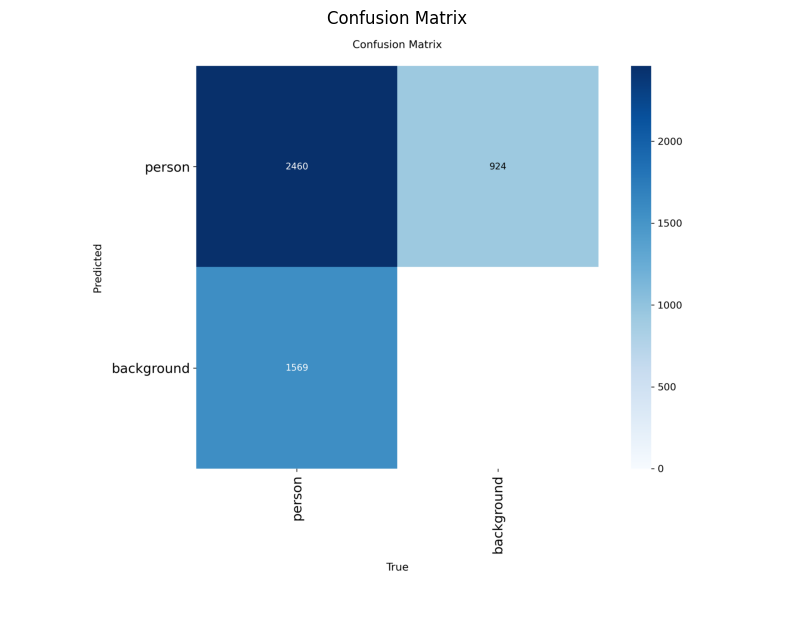

In [ ]:
# ================================
# 12. Confusion Matrix
# ================================
model.val(save_json=True)

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/yolo_person/model/confusion_matrix.png")

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

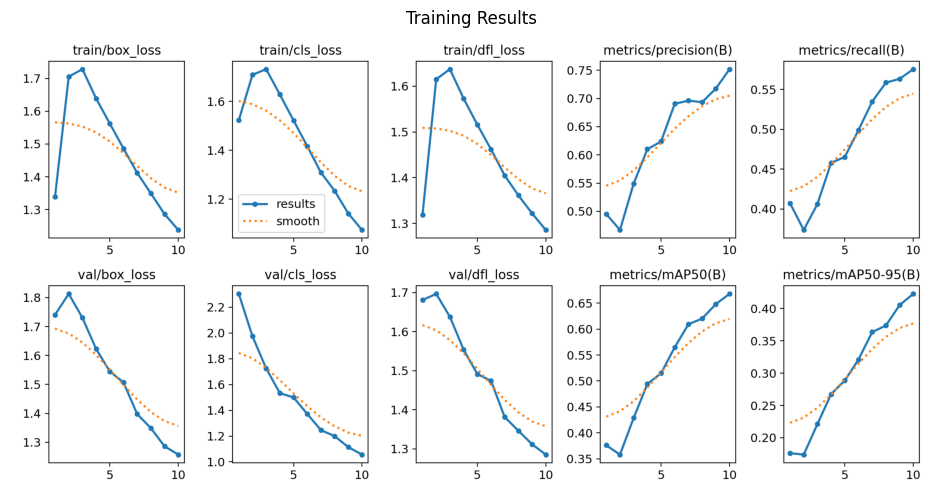

In [ ]:
# ================================
# 13. Grafik Training (Loss, mAP, dll)
# ================================
img = Image.open("/content/drive/MyDrive/yolo_person/model/results.png")

plt.figure(figsize=(12,6))
plt.imshow(img)
plt.axis("off")
plt.title("Training Results")
plt.show()


image 1/1 /content/drive/MyDrive/yolo_person/datasets/person/images/val/000000176595.jpg: 640x416 2 persons, 12.5ms
Speed: 1.4ms preprocess, 12.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 416)


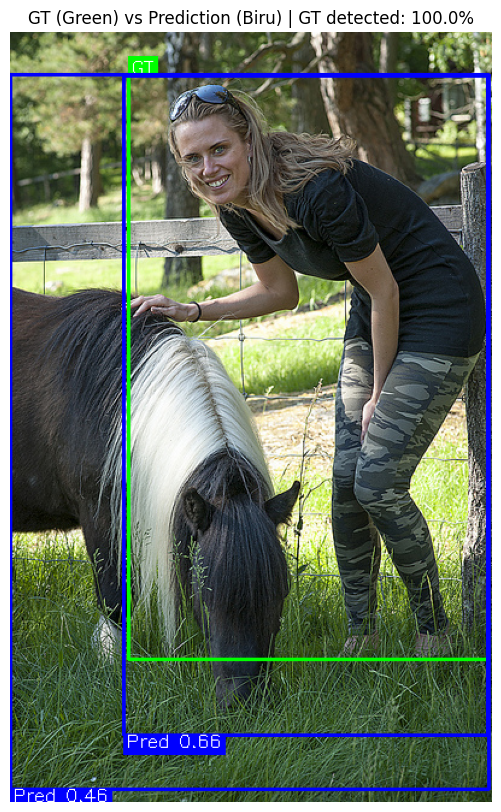

In [ ]:
# ================================
# 14. TEST IMAGE GROUND TRUTH VS PREDICTION
# ================================
import cv2
import os
import glob
import random
import matplotlib.pyplot as plt
import numpy as np

val_images = glob.glob(f"{DATASET_DIR}/images/val/*.jpg")
sample_images = random.sample(val_images, 1)

def iou(boxA, boxB):
    # box = [x1, y1, x2, y2]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

def draw_gt_and_pred(img_path, iou_thresh=0.5):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    gt_boxes = []
    # ======================
    # DRAW GROUND TRUTH (HIJAU)
    # ======================
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                cls, x, y, bw, bh = map(float, line.strip().split())
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)
                gt_boxes.append([x1, y1, x2, y2])

                # Kotak GT
                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

                # Text overlay dengan background hijau & teks putih
                text = "GT"
                (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(img, (x1, y1-text_h-4), (x1+text_w+4, y1), (0,255,0), -1)
                cv2.putText(img, text, (x1+2, y1-2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    # ======================
    # DRAW PREDICTION (BIRU)
    # ======================
    results = model(img_path, conf=0.25)[0]
    pred_boxes = []
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        pred_boxes.append([x1, y1, x2, y2])

        # Kotak prediksi
        cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)

        # Text overlay dengan background biru & teks putih
        text = f"Pred {conf:.2f}"
        (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y2), (x1+text_w+4, y2+text_h+4), (255,0,0), -1)
        cv2.putText(img, text, (x1+2, y2+text_h-2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    # ======================
    # HITUNG PERSENTASE GT TERDETEKSI
    # ======================
    detected = 0
    for gt in gt_boxes:
        for pred in pred_boxes:
            if iou(gt, pred) >= iou_thresh:
                detected += 1
                break  # satu GT cukup satu prediksi
    total_gt = len(gt_boxes)
    percent_detected = (detected / total_gt * 100) if total_gt > 0 else 0

    return img, percent_detected

# ======================
# SHOW RESULT
# ======================
for img_path in sample_images:
    overlay_img, percent_gt = draw_gt_and_pred(img_path)
    overlay_img = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15,10))
    plt.imshow(overlay_img)
    plt.title(f"GT (Green) vs Prediction (Biru) | GT detected: {percent_gt:.1f}%")
    plt.axis("off")
    plt.show()

In [ ]:
# ================================
# IoU (Intersection over Union)
# ================================
results = model.predict(img_path, save=False)

result = results[0]

# ambil IoU terhadap ground truth (kalau ada label)
ious = result.boxes.iou if hasattr(result.boxes, 'iou') else None

print("IoU:", ious)


image 1/1 /content/drive/MyDrive/yolo_person/datasets/person/images/val/000000176595.jpg: 640x416 2 persons, 11.7ms
Speed: 2.2ms preprocess, 11.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 416)
IoU: None


In [ ]:
# ================================
# Confidence Score
# ================================
scores = result.boxes.conf.cpu().numpy()

for s in scores:
    print(f"Confidence: {s:.3f}")

Confidence: 0.658
Confidence: 0.462


Saving people1.jpg to people1 (2).jpg

image 1/1 /content/coco_temp/people1 (2).jpg: 480x640 5 persons, 14.1ms
Speed: 3.3ms preprocess, 14.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)


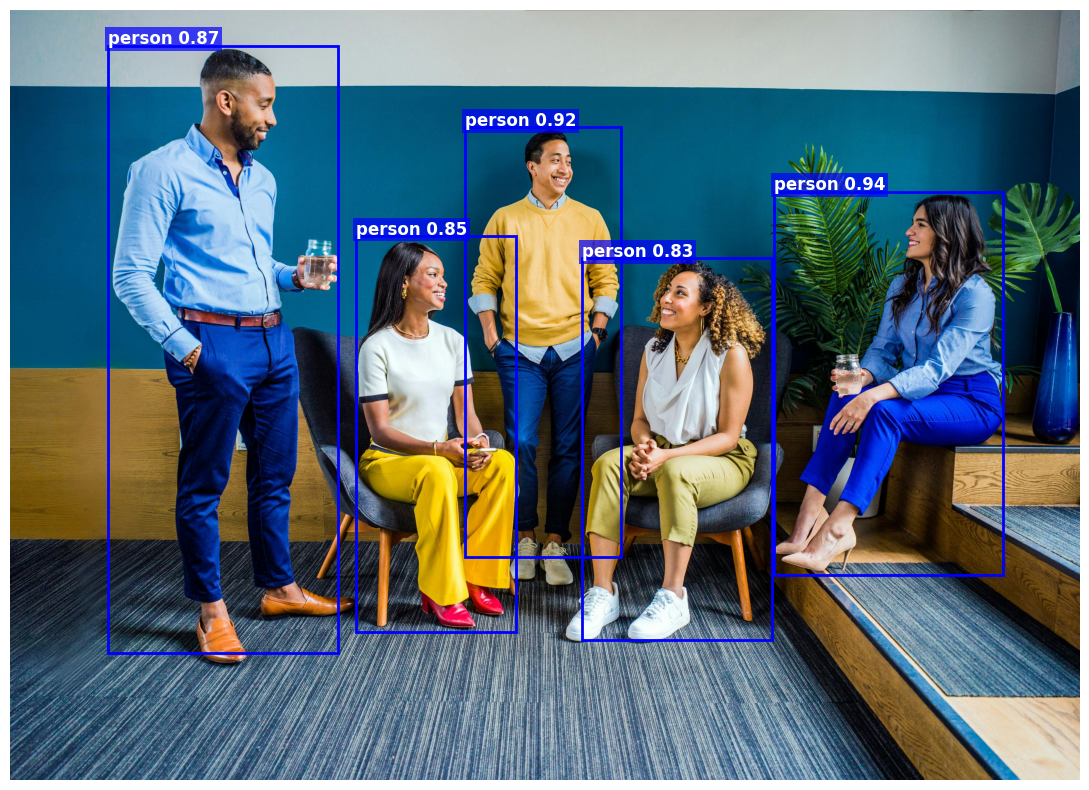

In [ ]:
# ================================
# 15. TEST IMAGE DARI UPLOAD
# ================================
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Upload gambar dari komputer
uploaded = files.upload()

for filename in uploaded.keys():
    # Load image
    img_path = filename
    img = Image.open(img_path)

    # Prediksi bounding box
    results = model.predict(img_path, imgsz=640, conf=0.25)  # conf bisa diubah

    # Plot hasil prediksi
    result = results[0]  # YOLOv8 selalu mengembalikan list
    boxes = result.boxes.xyxy.cpu().numpy()  # bounding box xyxy
    scores = result.boxes.conf.cpu().numpy()
    labels = result.boxes.cls.cpu().numpy()

    # Nama kelas dari model
    class_names = model.names

    plt.figure(figsize=(15,10))
    plt.imshow(img)
    ax = plt.gca()

    # Gambar bounding box dengan label biru & tulisan putih
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        class_name = class_names[int(label)]

        # Bounding box
        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            color="blue",
            linewidth=2
        )
        ax.add_patch(rect)

        # Label dengan background biru & teks putih
        ax.text(
            x1,
            y1 - 5,
            f"{class_name} {score:.2f}",
            color="white",
            fontsize=12,
            weight="bold",
            bbox=dict(facecolor='blue', alpha=0.7, pad=2, edgecolor='none')
        )

    plt.axis("off")
    plt.show()

In [ ]:
# ================================
# IoU (Intersection over Union)
# ================================
results = model.predict(img_path, save=False)

result = results[0]

# ambil IoU terhadap ground truth (kalau ada label)
ious = result.boxes.iou if hasattr(result.boxes, 'iou') else None

print("IoU:", ious)


image 1/1 /content/coco_temp/people1 (2).jpg: 480x640 5 persons, 12.9ms
Speed: 2.8ms preprocess, 12.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
IoU: None


In [ ]:
# ================================
#  Confidence Score
# ================================
scores = result.boxes.conf.cpu().numpy()

for s in scores:
    print(f"Confidence: {s:.3f}")

Confidence: 0.938
Confidence: 0.923
Confidence: 0.875
Confidence: 0.848
Confidence: 0.834


In [ ]:
# ================================
# 16. UPLOAD VIDEO & DETEKSI OBJECT
# ================================
from google.colab import files
uploaded = files.upload()

import cv2
import subprocess
import os
from ultralytics import YOLO

video_path = list(uploaded.keys())[0]
output_path = "/content/drive/MyDrive/yolo_person/output_yolov8.mp4"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

# ================================
# LOAD MODEL
# ================================
LOAD_DIR = "/content/drive/MyDrive/yolo_person/model"
model = YOLO(f"{LOAD_DIR}/best.pt")

# ================================
# BACA VIDEO
# ================================
cap = cv2.VideoCapture(video_path)

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)

if fps == 0:
    fps = 25

print("Resolusi:", width, "x", height)
print("FPS:", fps)

# ================================
# SETUP FFmpeg PIPE
# ================================
ffmpeg_cmd = [
    "ffmpeg",
    "-y",
    "-f", "rawvideo",
    "-vcodec", "rawvideo",
    "-pix_fmt", "bgr24",
    "-s", f"{width}x{height}",
    "-r", str(fps),
    "-i", "-",
    "-an",
    "-vcodec", "libx264",
    "-pix_fmt", "yuv420p",
    output_path
]

proc = subprocess.Popen(ffmpeg_cmd, stdin=subprocess.PIPE)

print("Processing video...")

# ================================
# PROCESS FRAME
# ================================
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # YOLO inference
    results = model.predict(frame, conf=0.3)

    annotated_frame = results[0].plot()

    # Pastikan ukuran sesuai
    if annotated_frame.shape[1] != width or annotated_frame.shape[0] != height:
        annotated_frame = cv2.resize(annotated_frame, (width, height))

    # Kirim ke FFmpeg
    proc.stdin.write(annotated_frame.tobytes())

# ================================
# CLEANUP
# ================================
cap.release()
proc.stdin.close()
proc.wait()

print("✅ Selesai!")
print("📁 Video:", output_path)

# ================================
# CEK FILE
# ================================
print("Size:", os.path.getsize(output_path))

In [ ]:
# ================================
# 17. TAMPILKAN HASIL VIDEO
# ================================
from IPython.display import HTML
from base64 import b64encode

output_path = "/content/drive/MyDrive/yolo_person/output_yolov8.mp4"
mp4 = open(output_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="640" height="480" controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")